In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import cv2

In [3]:
df = pd.read_csv('additional_train.csv')

In [5]:
df_sub = pd.read_csv('sample_submission.csv')

In [6]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [7]:
df_train.head()

,image_id,image_path,writer_id,pen_id
0,4,images/00004.png,W27,8
1,5,images/00005.png,W17,1
2,7,images/00007.png,W01,8
3,8,images/00008.png,W17,5
4,9,images/00009.png,W24,4


In [8]:
df_test.head()

,image_id,image_path
0,v2_8eb750cb7bac5c42036af72b8253976b,images/v2_8eb750cb7bac5c42036af72b8253976b.png
1,v2_04e19b0acea03fe2ae474ce8a4c6b705,images/v2_04e19b0acea03fe2ae474ce8a4c6b705.png
2,v2_6b3400d5252124adcc9859cbc78c5d8a,images/v2_6b3400d5252124adcc9859cbc78c5d8a.png
3,v2_79025cb2ef36af3dc15c91056fa225dc,images/v2_79025cb2ef36af3dc15c91056fa225dc.png
4,v2_3ed2f62c32c69ec191b7e5b86433cb87,images/v2_3ed2f62c32c69ec191b7e5b86433cb87.png


In [9]:
df_sub.head()

,image_id,writer_id
0,v2_000010c19b698fe39922ef49ff26ce16,W46
1,v2_000f8ac7d2e0ecf1d336c60fe7f34789,W39
2,v2_001a7e63cc91c92d259c2bc43572824f,W15
3,v2_001dd98a324ee7d88952f2e1d0c29674,W15
4,v2_002e3bc1d82ac5121dccf470ceed4422,W12


In [10]:
df.head()

,image_id,image_path,writer_id,pen_id
0,1,images/00001.png,W11,3
1,2,images/00002.png,-1,6
2,3,images/00003.png,W35,4
3,6,images/00006.png,-1,1
4,14,images/00014.png,W07,3


In [11]:
df_sub

,image_id,writer_id
0,v2_000010c19b698fe39922ef49ff26ce16,W46
1,v2_000f8ac7d2e0ecf1d336c60fe7f34789,W39
2,v2_001a7e63cc91c92d259c2bc43572824f,W15
3,v2_001dd98a324ee7d88952f2e1d0c29674,W15
4,v2_002e3bc1d82ac5121dccf470ceed4422,W12
...,...,...
5900,v2_ff9ddf7e74c701468f683c0f9808072b,W46
5901,v2_ffaebe819cd5e0ad88361aca2b5b5028,W27
5902,v2_ffb188fe23bd0d35707cab40ddeb7f5c,W32
5903,v2_ffdb1b6f3db5bfb421040965448ca40a,W19


In [19]:
from sklearn.preprocessing import LabelEncoder

In [20]:
label = LabelEncoder()

In [21]:
X_train = []
y_train = label.fit_transform(df_train['writer_id'])
for i in range(len(df_train)):
    image_path = df_train.iloc[i]['image_path']
    image = mpimg.imread(image_path)
    image = cv2.resize(image, (150, 150))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    image = image.reshape(150, 150, 1)
    X_train.append(image)
X_train = np.array(X_train)

In [26]:
X_train.shape

(23850, 150, 150, 1)

In [28]:
y_train.shape

(23850,)

In [33]:
len(label.classes_)

44

In [29]:
X_test = []
for i in range(len(df_test)):
    image_path = df_test.iloc[i]['image_path']
    image = mpimg.imread(image_path)
    image = cv2.resize(image, (150, 150))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    image = image.reshape(150, 150, 1)
    X_test.append(image)
X_test = np.array(X_test)

In [30]:
X_test.shape

(5905, 150, 150, 1)

In [31]:
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam

In [38]:
from keras.utils import to_categorical

In [39]:
y_train = to_categorical(y_train, num_classes=44)

In [40]:
model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(150, 150, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=44, activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

C:\Users\ASUS\Desktop\ML_18-35_Hrach\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
model.fit(X_train, y_train, validation_split=0.15, epochs=5)

Epoch 1/5
634/634 ━━━━━━━━━━━━━━━━━━━━ 58s 88ms/step - accuracy: 0.1372 - loss: 3.2287 - val_accuracy: 0.2331 - val_loss: 2.6731
Epoch 2/5
634/634 ━━━━━━━━━━━━━━━━━━━━ 56s 88ms/step - accuracy: 0.3276 - loss: 2.3663 - val_accuracy: 0.3385 - val_loss: 2.2890
Epoch 3/5
634/634 ━━━━━━━━━━━━━━━━━━━━ 82s 88ms/step - accuracy: 0.4150 - loss: 2.0400 - val_accuracy: 0.3921 - val_loss: 2.1369
Epoch 4/5
634/634 ━━━━━━━━━━━━━━━━━━━━ 82s 88ms/step - accuracy: 0.4841 - loss: 1.7866 - val_accuracy: 0.4441 - val_loss: 1.9539
Epoch 5/5
634/634 ━━━━━━━━━━━━━━━━━━━━ 82s 88ms/step - accuracy: 0.5418 - loss: 1.5721 - val_accuracy: 0.4544 - val_loss: 1.9358


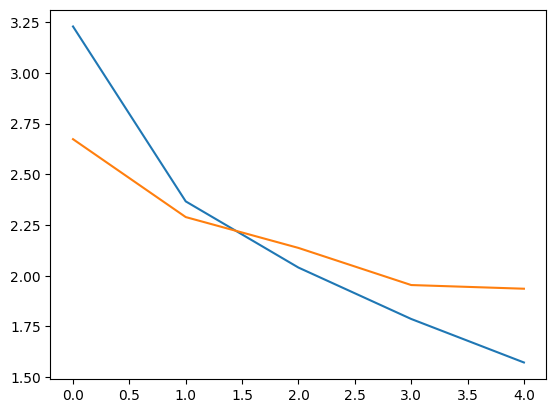

In [42]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

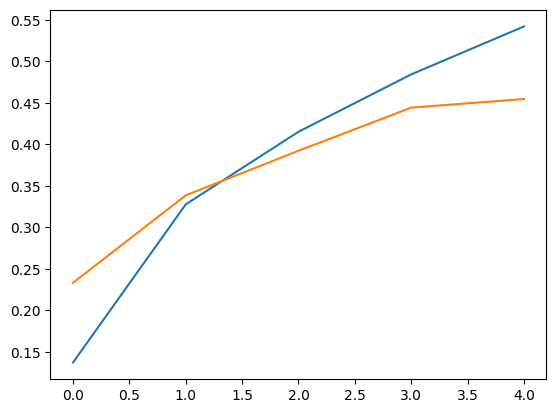

In [43]:
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])